<a href="https://colab.research.google.com/github/selviij/NLP--Processing/blob/main/Indonesian_Twitter_Sentiment_Analysis_Dataset_PPKM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pprint import pprint
from collections import Counter
import string
import re
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import classification_report

In [78]:
import nltk

# Download the 'punkt_tab' resource
nltk.download('punkt_tab')

# ... (rest of your code)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [26]:
df = pd.read_csv("INA_TweetsPPKM_Labeled_Pure.csv", sep="\t")
df.drop(columns=["Date", "User"], inplace=True)
df.head()

,Tweet,sentiment
0,Ketahui informasi pembagian #PPKM di wilayah J...,1
1,Tempat Ibadah di Wilayah PPKM Level 1 Boleh Be...,1
2,"Juru bicara Satgas Covid-19, Wiku Adisasmito m...",1
3,Ketahui informasi pembagian #PPKM di wilayah J...,1
4,Kementerian Agama menerbitkan Surat Edaran Nom...,1


In [4]:
df["Tweet"] = df["Tweet"].str.lower()
df.head()

,Tweet,sentiment
0,ketahui informasi pembagian #ppkm di wilayah j...,1
1,tempat ibadah di wilayah ppkm level 1 boleh be...,1
2,"juru bicara satgas covid-19, wiku adisasmito m...",1
3,ketahui informasi pembagian #ppkm di wilayah j...,1
4,kementerian agama menerbitkan surat edaran nom...,1


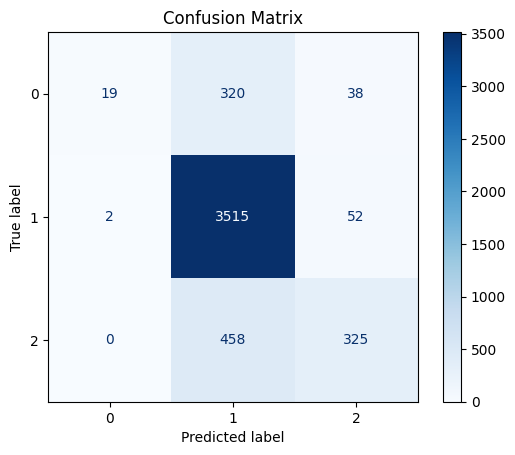


Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.05      0.10       377
           1       0.82      0.98      0.89      3569
           2       0.78      0.42      0.54       783

    accuracy                           0.82      4729
   macro avg       0.84      0.48      0.51      4729
weighted avg       0.82      0.82      0.77      4729



In [79]:
# 2. Preprocessing function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)           # Hapus URL
    text = re.sub(r"@\w+", "", text)                     # Hapus mention
    text = re.sub(r"#", "", text)                        # Hapus simbol #
    text = re.sub(r"\d+", "", text)                      # Hapus angka
    text = text.translate(str.maketrans('', '', string.punctuation))  # Hapus tanda baca
    tokens = word_tokenize(text)                         # Tokenisasi
    stop_words = set(stopwords.words("indonesian"))      # Stopwords Indo
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

# 3. Bersihkan teks
# df = df.dropna(subset=['Tweet', 'Label'])  # Buang jika ada NaN - Original line causing the error
df = df.dropna(subset=['Tweet', 'sentiment'])  # Buang jika ada NaN - Changed 'Label' to 'sentiment'
df['clean_text'] = df['Tweet'].apply(clean_text)

# 4. TF-IDF vektorisasi
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
# y = df['Label'] # Original line causing the error
y = df['sentiment'] # Changed 'Label' to 'sentiment'

# 5. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Training Multinomial Naive Bayes
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# 8. Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

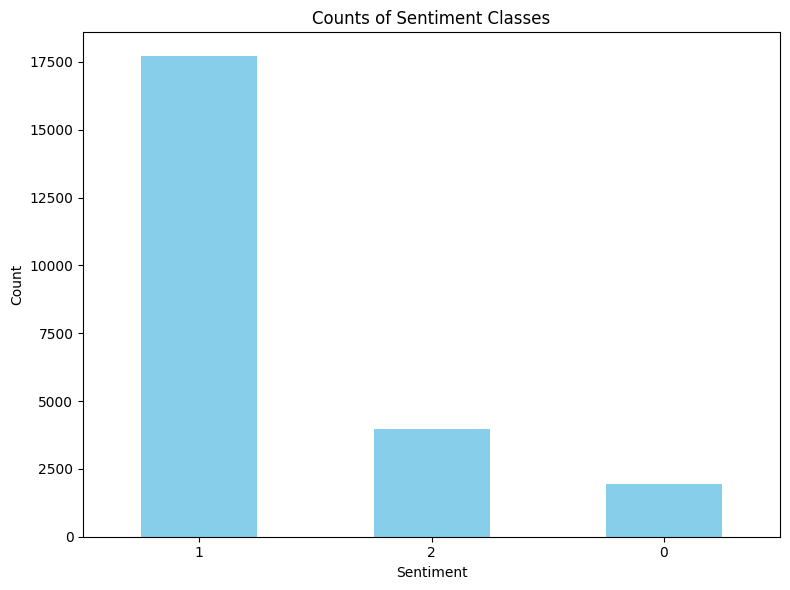

In [5]:
sentiment_counts = df['sentiment'].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 6))
sentiment_counts.plot(kind='bar', color='skyblue')
plt.title('Counts of Sentiment Classes')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

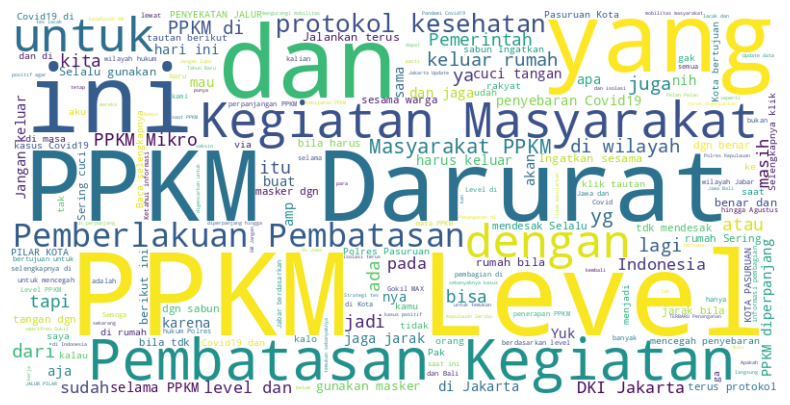

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['Tweet'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [38]:
X = df["Tweet"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
                                        X, y,
                                        stratify=y,
                                        test_size=0.2,
                                        random_state=420
                                    )

bow_lr_pipeline = Pipeline([
    ('count_vectorizer', CountVectorizer()),
    ('logistic_regression', LogisticRegression(max_iter=1000))
])

tfidf_lr_pipeline = Pipeline([
    ('tfidf_vectorizer', TfidfVectorizer()),
    ('logistic_regression', LogisticRegression(max_iter=1000))
])

tfidf_lsa_lr_pipeline = Pipeline([
    ('tfidf_vectorizer', TfidfVectorizer()),
    ('lsa', TruncatedSVD(n_components=20)),
    ('logistic_regression', LogisticRegression(max_iter=1000)),
])

In [39]:
bow_lr_pipeline

Pipeline(steps=[('count_vectorizer', CountVectorizer()),
                ('logistic_regression', LogisticRegression(max_iter=1000))])

In [40]:
tfidf_lr_pipeline

Pipeline(steps=[('tfidf_vectorizer', TfidfVectorizer()),
                ('logistic_regression', LogisticRegression(max_iter=1000))])

In [41]:
tfidf_lsa_lr_pipeline

Pipeline(steps=[('tfidf_vectorizer', TfidfVectorizer()),
                ('lsa', TruncatedSVD(n_components=20)),
                ('logistic_regression', LogisticRegression(max_iter=1000))])

In [42]:
bow_lr_pipeline.fit(X_train, y_train)
bow_lr_preds = bow_lr_pipeline.predict(X_test)
print(classification_report(y_test, bow_lr_preds, digits=5))

              precision    recall  f1-score   support

           0    0.65234   0.42602   0.51543       392
           1    0.88434   0.95227   0.91705      3541
           2    0.73030   0.60553   0.66209       796

    accuracy                        0.85029      4729
   macro avg    0.75566   0.66127   0.69819      4729
weighted avg    0.83918   0.85029   0.84084      4729



In [43]:
tfidf_lr_pipeline.fit(X_train, y_train)
tfidf_lr_preds = tfidf_lr_pipeline.predict(X_test)
print(classification_report(y_test, tfidf_lr_preds, digits=5))

              precision    recall  f1-score   support

           0    0.74214   0.30102   0.42831       392
           1    0.86830   0.96075   0.91219      3541
           2    0.73466   0.60176   0.66160       796

    accuracy                        0.84563      4729
   macro avg    0.78170   0.62117   0.66737      4729
weighted avg    0.83535   0.84563   0.82990      4729



In [44]:
tfidf_lsa_lr_pipeline.fit(X_train, y_train)
tfidf_lsa_lr_preds = tfidf_lsa_lr_pipeline.predict(X_test)
print(classification_report(y_test, tfidf_lsa_lr_preds, digits=5))

              precision    recall  f1-score   support

           0    0.51020   0.06378   0.11338       392
           1    0.80218   0.95510   0.87199      3541
           2    0.53017   0.30905   0.39048       796

    accuracy                        0.77247      4729
   macro avg    0.61419   0.44264   0.45861      4729
weighted avg    0.73219   0.77247   0.72805      4729

